In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

1. Викачати та підготувати дані
   
a) Завантажити датасет за допомогою функції fetch_openml.

b) Вивести форму матриці X і кількість унікальних міток у y.

c)Для попереднього огляду візуалізувати кілька прикладів зображень (наприклад, 10 випадкових цифр) у вигляді 28×28 пікселів.

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X matrix shape:  (70000, 784)
amount of unique y marks:  10


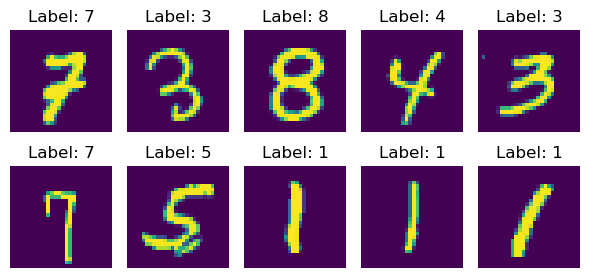

In [3]:
print("X matrix shape: ", X.shape)
print("amount of unique y marks: ", len(np.unique(y)))
plt.figure(figsize=(6, 3))
rand_index = np.random.choice(X.shape[0], 10, replace=False)
for i, index in enumerate(rand_index):
    plt.subplot(2, 5, i + 1)
    image = X[index].reshape(28, 28)
    plt.imshow(image, cmap="viridis")
    plt.title(f"Label: {y[index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

2. Реалізувати метод головних компонент (PCA)

a) Реалізувати PCA із кількістю компонент n_components=3.

b) Отримати матрицю проєкцій (X_pca) розміром (70000 × 3);

c) Вивести відсоток поясненої дисперсії для кожної компоненти (explained_variance_ratio_).

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
for i, var_ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC_{i}: {var_ratio}")

PC_0: 0.09746115922494741
PC_1: 0.07155444586878708
PC_2: 0.06149530980723033


3. Візуалізувати дані у просторі перших трьох компонент

a) Побудувати 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних (використати matplotlib.axes3d або plotly). Точки зафарбувати відповідно до класу цифри.

b) Проаналізувати, чи видно кластери для різних цифр, наскільки добре PCA відділяє класи у тривимірному просторі.

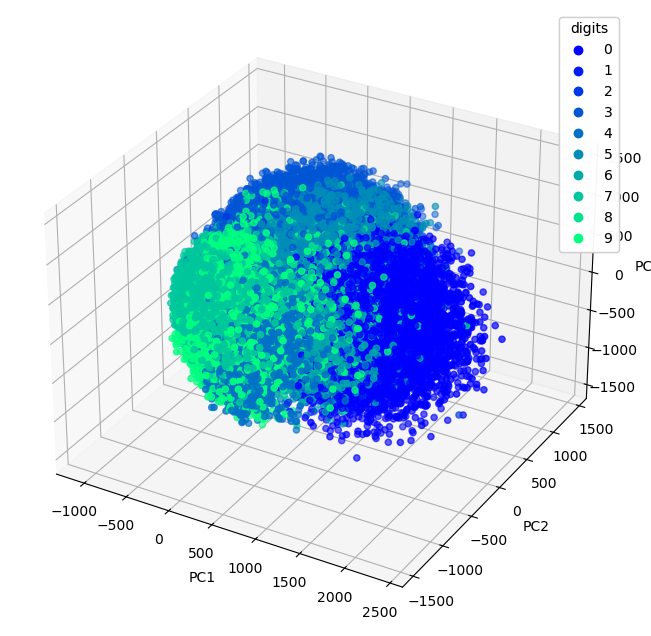

In [5]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=y.astype(int), cmap=plt.cm.winter)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
legend = ax.legend(*scatter.legend_elements(), title="digits")
ax.add_artist(legend)
plt.show()

4. Реконструкція зображень після зменшення розмірності

a) Використати метод inverse_transform() з PCA для відновлення даних із простору трьох компонент у оригінальний простір.

b) Вивести кілька прикладів (наприклад, 10 випадкових цифр):
 
1 оригінальне зображення;
 
2 реконструйоване після PCA з трьома компонентами.

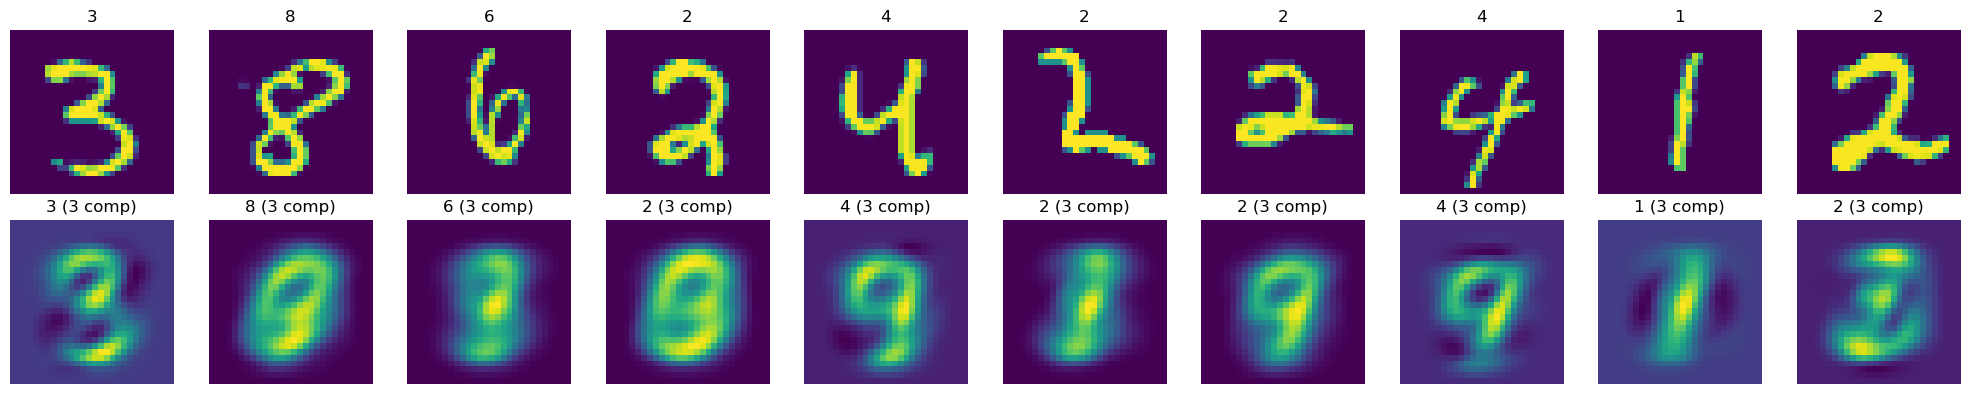

In [6]:
X_recovered = pca.inverse_transform(X_pca)
num_images = 10
indices = np.random.choice(len(X), num_images, replace=False)

plt.figure(figsize=(20, 4))
for i, index in enumerate(indices):
    plt.subplot(2, num_images, i + 1)
    plt.imshow(X[index].reshape(28, 28), cmap='viridis')
    plt.title(f"{y[index]}")
    plt.axis('off')
    
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(X_recovered[index].reshape(28, 28), cmap='viridis') 
    plt.title(f"{y[index]} (3 comp)")
    plt.axis('off')

plt.tight_layout()
plt.show()

5. Проаналізувати залежність між помилкою реконструкції та кількістю компонент

a) Визначити помилку реконструкції (Mean Squared Error, MSE) як середнє квадратів різниці між початковими та реконструйованими значеннями пікселів.

b) Обчислити MSE(k) та відсоток поясненої дисперсії для різної кількості компонент k і побудувати відповідні графіки.

   k          MSE     Dispersion
--------------------------------
   1      3948.58          9.75%
   5      2916.20         33.34%
  10      2234.86         48.92%
  15      1835.48         58.05%
  30      1174.10         73.16%
  50       763.79         82.54%
 100       372.02         91.50%
 250        95.51         97.82%


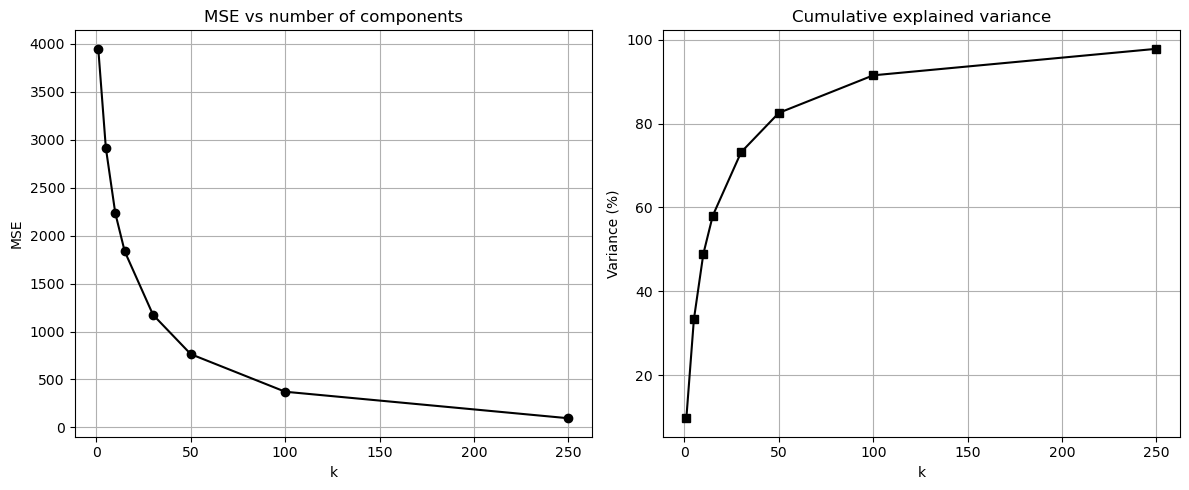

In [11]:
from sklearn.metrics import mean_squared_error

components = [1, 5, 10, 15, 30, 50, 100, 250]
mse_list = []
variance_list = []

print(f"{'k':>4}   {'MSE':>10}   {'Dispersion':>12}")
print("-" * 32)

for c in components:
    pca_c = PCA(n_components=c)
    X_transformed = pca_c.fit_transform(X)
    X_reconstructed = pca_c.inverse_transform(X_transformed)

    mse = mean_squared_error(X, X_reconstructed)
    var_sum = np.sum(pca_c.explained_variance_ratio_) * 100
    
    mse_list.append(mse)
    variance_list.append(var_sum)
    
    print(f"{c:4}   {mse:10.2f}   {var_sum:11.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(components, mse_list, marker='o', color='black')
plt.title("MSE vs number of components")
plt.xlabel("k")
plt.ylabel("MSE")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(components, variance_list, marker='s', color='black')
plt.title("Cumulative explained variance")
plt.xlabel("k")
plt.ylabel("Variance (%)")
plt.grid(True)

plt.tight_layout()
plt.show()